In [16]:
import time

import numpy as np
from matplotlib import pyplot as plt
from torch import Tensor
from torch.nn import functional as F

from common import G2OpGymEnv, BusConnectivityGraphObsSpace
from nri import Encoder
from nri import prior_from_env
from nri.agent.graphormer.GraphormerEncoder import GraphormerNRIEncoder
from nri.agent.pretrain_encoder import create_dataset, GraphDataset
from nri.agent.pretrain_encoder import train
from visualization import PlottingArgs, visualize_graph
from visualization import get_node_styles

In [17]:
def get_env():
    return G2OpGymEnv(
        obs_space_creation=lambda e: BusConnectivityGraphObsSpace(e.observation_space, normalization_boundaries={
            "active_power_forecast": [-122.4, 116.666],
            "active_power": [-122.4, 116.666],
            "reactive_power_forecast": [-85.7, 107.228],
            "reactive_power": [-85.7, 107.228],
            "voltage": [-142.1, 142.1],
            "voltage_angle": [-14.212, 1.246],
            "current": [0, 1512],
            "rho": [0, 1]
        }))


eps = 0.0000001
prior_for_graph_edges = 1.0
ds_size = 100

# create prior and dataset
env = get_env()
prior = prior_from_env(prior_for_graph_edges, env)
ds: GraphDataset = create_dataset(env, prior, ds_size)
ds_test: GraphDataset = create_dataset(get_env(), prior, ds_size // 10)

2025-11-21 22:26:04,852 - common.constants - INFO - Using graph observation space with 57 nodes, ≤ 244 edges and 8 features per node (active_power_forecast, reactive_power_forecast, active_power, reactive_power, voltage, voltage_angle, current, rho).
2025-11-21 22:26:04,866 - common.constants - INFO - Prior for graph edges: tensor([1., 0.]), Prior for non graph edges: tensor([0.0361, 0.9639])
Create dataset: 100%|██████████| 100/100 [00:01<00:00, 97.91it/s]
2025-11-21 22:26:07,005 - common.constants - INFO - Using graph observation space with 57 nodes, ≤ 244 edges and 8 features per node (active_power_forecast, reactive_power_forecast, active_power, reactive_power, voltage, voltage_angle, current, rho).
Create dataset: 100%|██████████| 10/10 [00:00<00:00, 15.78it/s]


In [18]:
graphormer_encoder = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_layers=1, num_edge_types=2, max_degree=7, max_path_distance=9)
nri_encoder = Encoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_edge_types=2, dropout_prob=0.0)

results = {
    "Graphormer": {"loss": [], "time": -1},
    "NRI":  {"loss": [], "time": -1},
}

encoders = {
    "Graphormer": graphormer_encoder,
    "NRI": nri_encoder
}

for name, encoder in encoders.items():
    start = time.time()
    results[name]["loss"] = train(
        encoder=encoder,
        ds=ds,
        testing_ds=ds_test,
        batch_size=1,
        evaluate_every_k_epochs=1,
        num_epochs=20
    )
    results[name]["time"] = (time.time() - start)


Epoch 19, Loss: 0.00122241, Max Grads: 0.00, logits max: 0.00, Evaluation loss: 0.00155888: 100%|██████████| 20/20 [00:17<00:00,  1.14it/s]
Epoch 19, Loss: 0.00002283, Max Grads: 0.00, logits max: 9.30, Evaluation loss: 0.00003349: 100%|██████████| 20/20 [00:37<00:00,  1.89s/it]


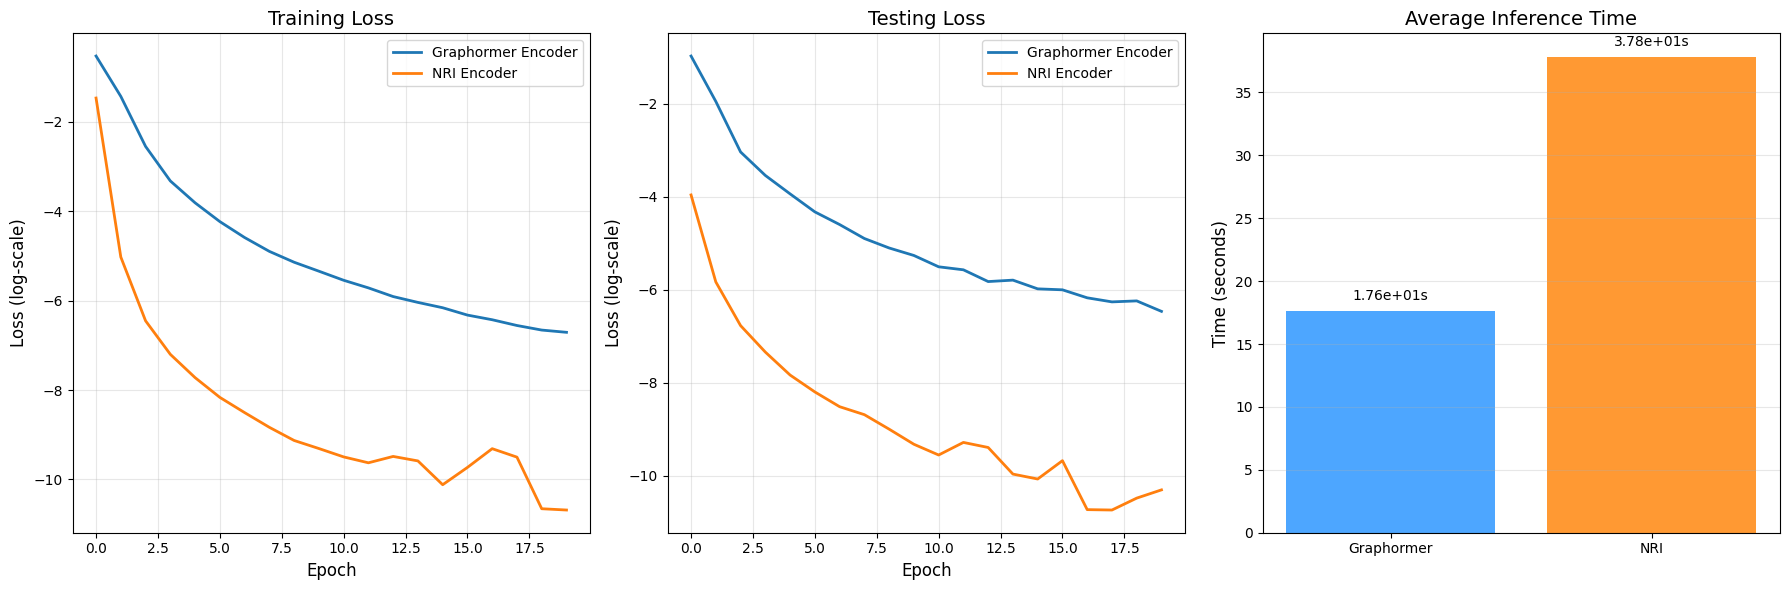

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ----- Loss Plot -----
graphormer_train_loss = np.log(np.array([train for train, _ in results["Graphormer"]["loss"]]) + eps)
nri_train_loss = np.log(np.array([train for train, _ in results["NRI"]["loss"]]) + eps)

axes[0].plot(graphormer_train_loss, label="Graphormer Encoder", linewidth=2)
axes[0].plot(nri_train_loss, label="NRI Encoder", linewidth=2)

axes[0].set_title("Training Loss", fontsize=14)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss (log-scale)", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# ----- Testing Loss Plot -----
graphormer_test_loss = np.log(np.array([test for _, test in results["Graphormer"]["loss"]], dtype=np.float32) + eps)
nri_test_loss = np.log(np.array([test for _, test in results["NRI"]["loss"]], dtype=np.float32) + eps)
x = np.arange(len(graphormer_test_loss))
graphormer_mask = ~np.isnan(graphormer_test_loss)
nri_mask = ~np.isnan(nri_test_loss)

axes[1].plot(x[graphormer_mask], graphormer_test_loss[graphormer_mask], label="Graphormer Encoder", linewidth=2)
axes[1].plot(x[nri_mask], nri_test_loss[nri_mask], label="NRI Encoder", linewidth=2)

axes[1].set_title("Testing Loss", fontsize=14)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Loss (log-scale)", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

# ----- Inference Time Bar Chart -----
methods = ["Graphormer", "NRI"]
values = [results["Graphormer"]["time"], results["NRI"]["time"]]

bars = axes[2].bar(methods, values, color=["#4da6ff", "#ff9933"])

# Add exact value labels above bars
for bar, val in zip(bars, values):
    axes[2].annotate(f"{val:.2e}s",
                     xy=(bar.get_x() + bar.get_width() / 2, val),
                     xytext=(0, 6),
                     textcoords="offset points",
                     ha="center", va="bottom",
                     fontsize=10)

axes[2].set_title("Average Inference Time", fontsize=14)
axes[2].set_ylabel("Time (seconds)", fontsize=12)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Graphormer encoder is able to approximate the prior equally well as the NRI Encoder. Since it has a more general understanding of the structure of the powergrid, it is likely better suited to make predictions for latent graph structures. Additionally, inference in the GT module is ~x9 faster.

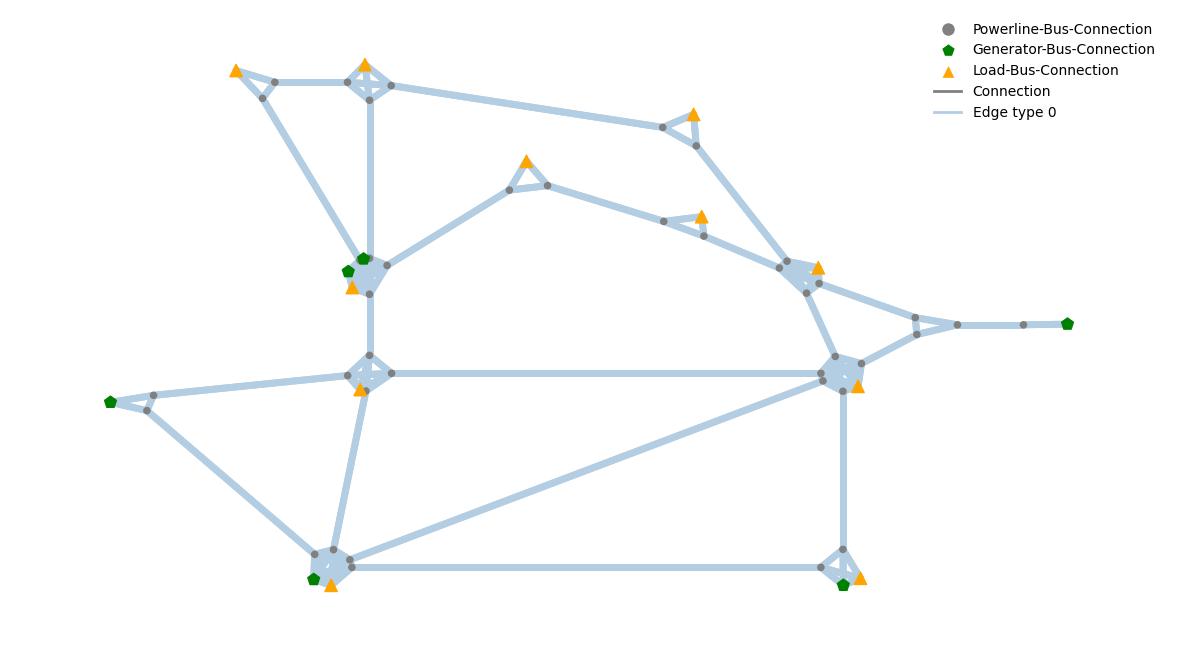

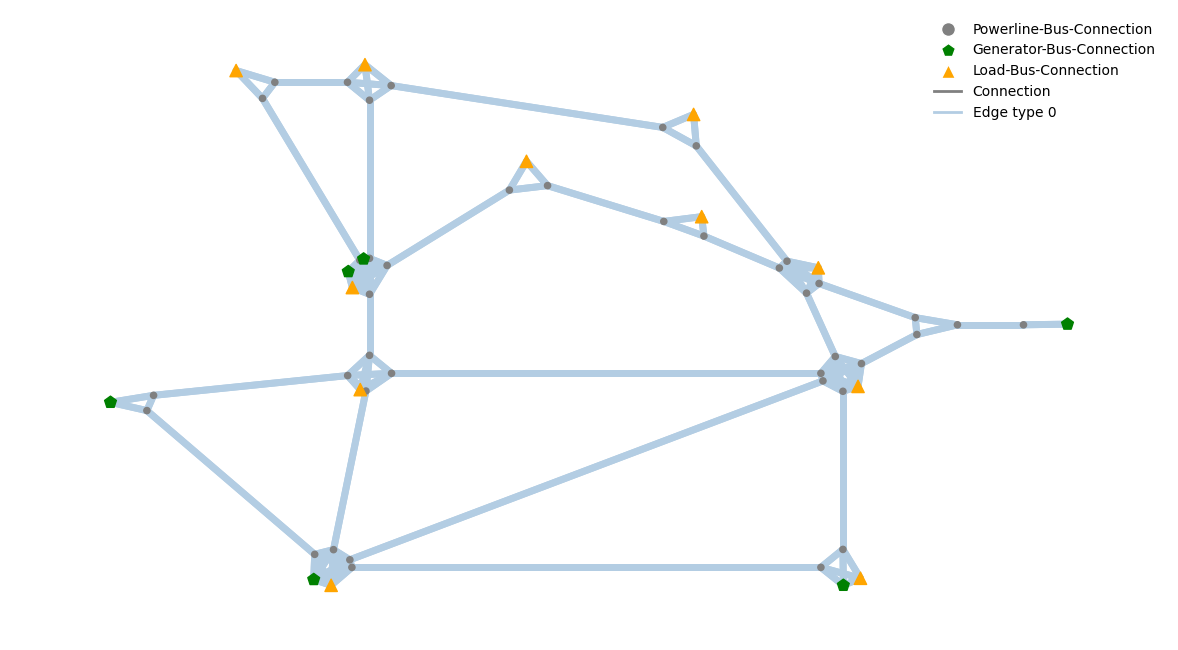

In [20]:
sample = ds_test.get(0)

x = sample.x
powerline_edge_index = sample.edge_index

for enc in [graphormer_encoder, nri_encoder]:
    encoder_logits: Tensor = enc.forward(x=x, powerline_edge_index=powerline_edge_index) # [E, K]
    p_z_given_x: Tensor = F.softmax(encoder_logits, dim=-1).detach().cpu().numpy() # [E, K]

    plotting_args = PlottingArgs(
        env.observation_space.num_nodes,
        get_node_styles(env._g2op_env, env.observation_space.__class__),
        powerline_edge_index=powerline_edge_index,
        latent_edge_probs=p_z_given_x,
    )
    visualize_graph(plotting_args)

In [27]:
loss_curves_per_run = []
n_runs = 7
for i in range(n_runs):
    graphormer_encoder_short = GraphormerNRIEncoder(x_dim=env.observation_space.x_dim, hidden_dim=16, num_layers=1, num_edge_types=2, max_degree=7, max_path_distance=9)
    loss_curve = train(graphormer_encoder_short, ds, num_epochs=20)
    loss_curves_per_run.append([train for train, _ in loss_curve])

Epoch 19, Loss: 0.37278558, Max Grads: 0.14, logits max: 0.00: 100%|██████████| 20/20 [00:02<00:00,  7.57it/s]
Epoch 19, Loss: 0.26873784, Max Grads: 0.10, logits max: 0.00: 100%|██████████| 20/20 [00:02<00:00,  8.34it/s]
Epoch 19, Loss: 0.09050755, Max Grads: 0.05, logits max: 0.00: 100%|██████████| 20/20 [00:02<00:00,  8.51it/s]
Epoch 19, Loss: 0.61283077, Max Grads: 0.10, logits max: 0.00: 100%|██████████| 20/20 [00:02<00:00,  8.57it/s]
Epoch 19, Loss: 0.58565956, Max Grads: 0.10, logits max: 0.00: 100%|██████████| 20/20 [00:02<00:00,  8.32it/s]
Epoch 19, Loss: 0.29921299, Max Grads: 0.09, logits max: 0.00: 100%|██████████| 20/20 [00:02<00:00,  8.79it/s]
Epoch 19, Loss: 0.39057271, Max Grads: 0.23, logits max: 0.00: 100%|██████████| 20/20 [00:02<00:00,  8.86it/s]


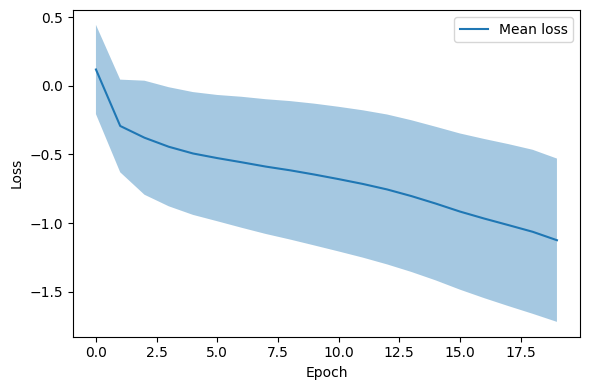

In [28]:
loss_arr = np.log(np.array(loss_curves_per_run) + eps)
mean_loss = loss_arr.mean(axis=0)
std_loss = loss_arr.std(axis=0)
epochs = np.arange(loss_arr.shape[1])

plt.figure(figsize=(6,4))
plt.plot(epochs, mean_loss, label="Mean loss")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, alpha=0.4)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()